In [1]:
%config InlineBackend.figure_format = 'retina'

import numpy as np
import matplotlib as plt
import pandas as pd

from pathlib import Path
import xml.etree.ElementTree as ET

In [2]:
REPO_ROOT = Path.cwd().parent
DATA_DIR = REPO_ROOT / "data"

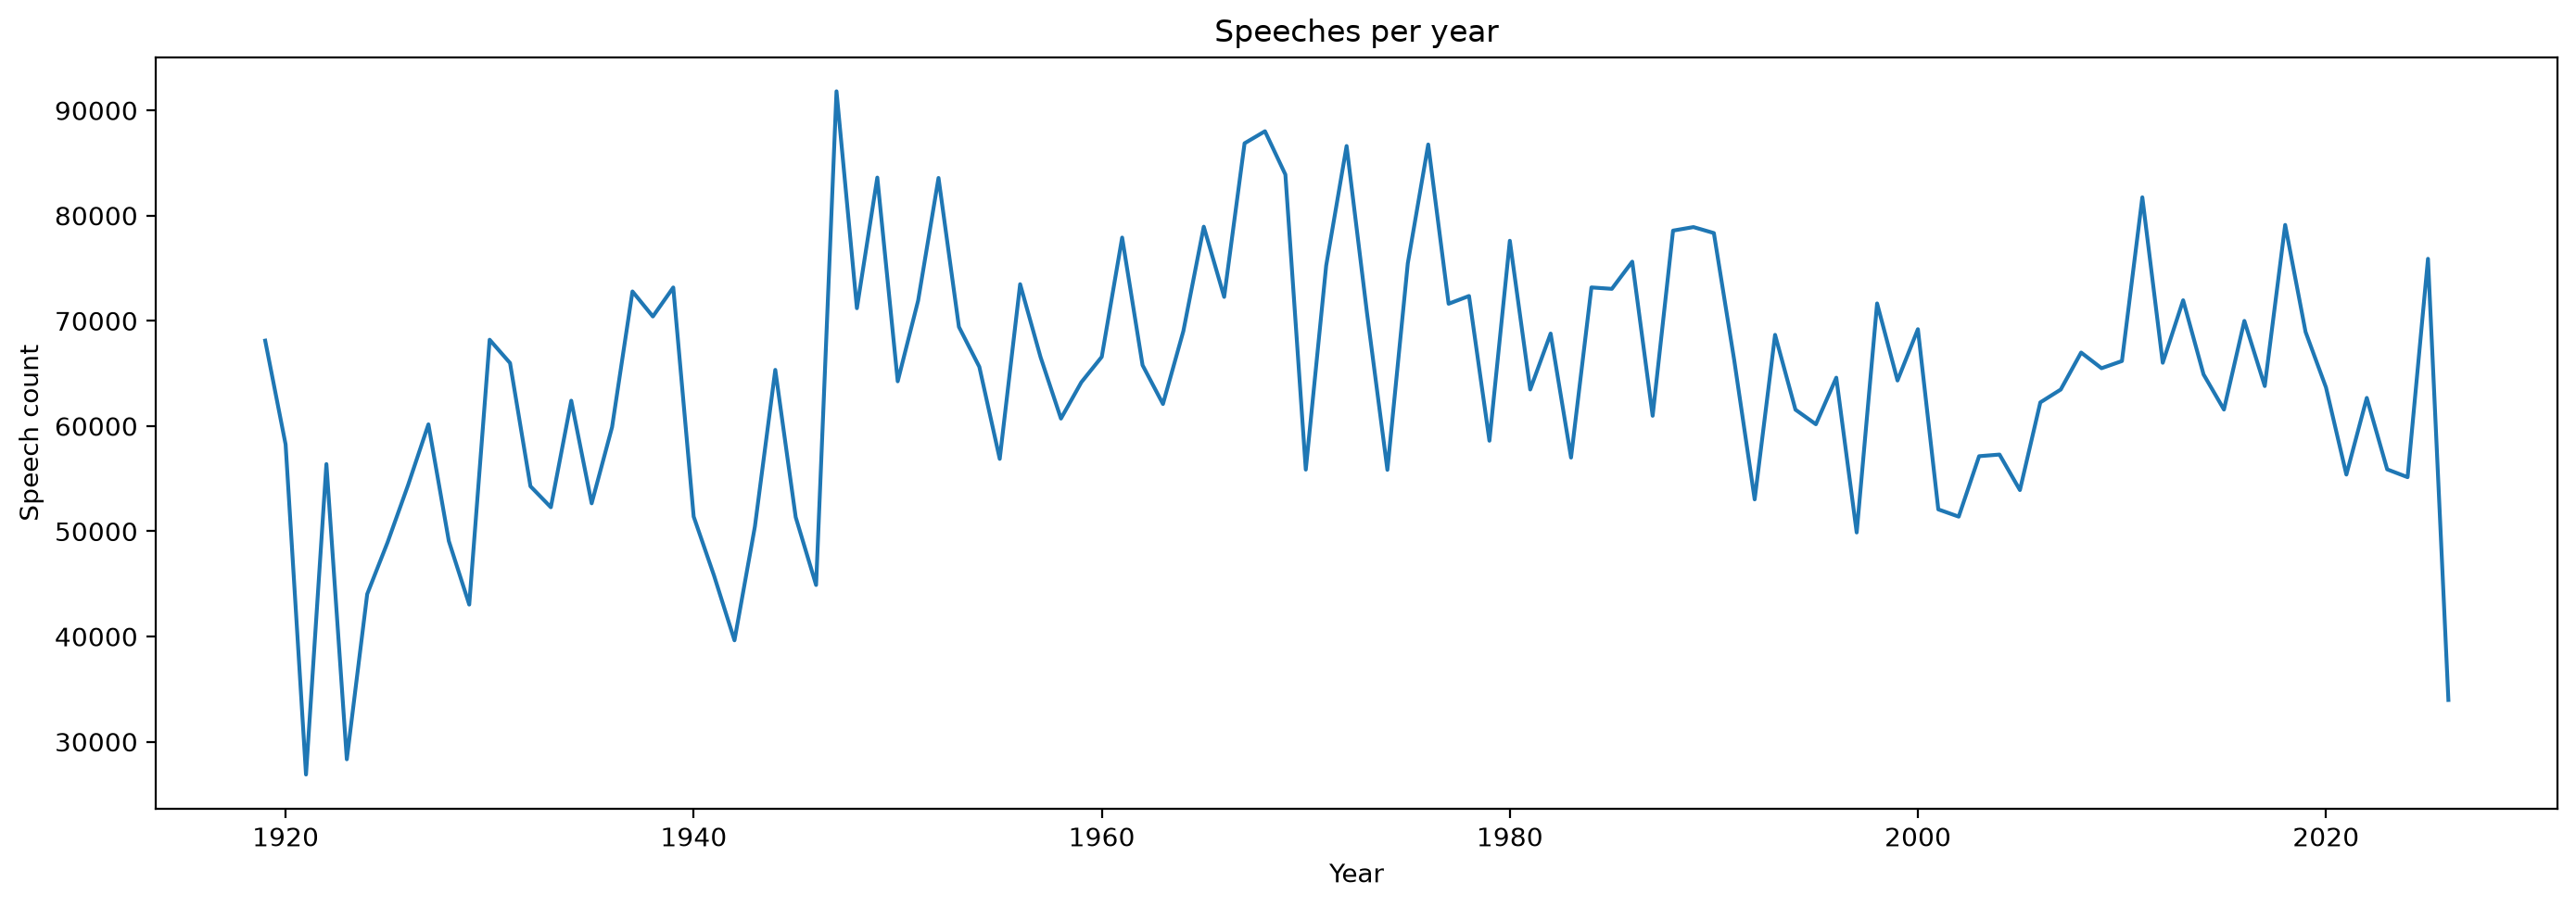

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet(DATA_DIR / 'debates.parquet', columns=['year'])

speech_count = df.groupby('year').size()

plt.figure(figsize=(14, 5))
plt.plot(speech_count.index, speech_count.values)
plt.xlabel('Year')
plt.ylabel('Speech count')
plt.title('Speeches per year')
plt.tight_layout()
plt.show()

In [5]:
import pyarrow.parquet as pq

schema = pq.read_schema(DATA_DIR / 'debates.parquet')
print(schema)

id: large_string
date: large_string
year: int64
url: string
time: string
person_id: string
speakerid: string
speakername: large_string
nospeaker: string
type: string
oral_qnum: string
text: large_string
-- schema metadata --
pandas: '{"index_columns": [], "column_indexes": [], "columns": [{"name":' + 1418


In [6]:
df = pd.read_parquet(DATA_DIR / 'debates.parquet', columns=['id'])

print(df['id'].duplicated().sum())
print(df['id'][0])


2036
uk.org.publicwhip/debate/1919-02-04a.1.1


id is not unique and cannot be used. I'll rename id to source_id and then set up a new unique integer id to idenitfy each row.